In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAG_TOKEN')

In [5]:
!mkdir -p /content/drive/MyDrive/KaggleData/Titanic
!kaggle competitions download -c titanic -p /content/drive/MyDrive/KaggleData/Titanic
!unzip -o /content/drive/MyDrive/KaggleData/Titanic/titanic.zip -d /content/drive/MyDrive/KaggleData/Titanic


100% 34.1k/34.1k [00:00<00:00, 2.81MB/s]

Archive:  /content/drive/MyDrive/KaggleData/Titanic/titanic.zip
  inflating: /content/drive/MyDrive/KaggleData/Titanic/gender_submission.csv  
  inflating: /content/drive/MyDrive/KaggleData/Titanic/test.csv  
  inflating: /content/drive/MyDrive/KaggleData/Titanic/train.csv  


In [6]:
!ls /content/drive/MyDrive/KaggleData/Titanic

gender_submission.csv  test.csv  titanic.zip  train.csv


# Loading Files

In [7]:
import numpy as np
import pandas as pd

path = '/content/drive/MyDrive/KaggleData/Titanic/train.csv'
df = pd.read_csv(path)

# Basic EDA

In [8]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [9]:
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [10]:
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Visualization

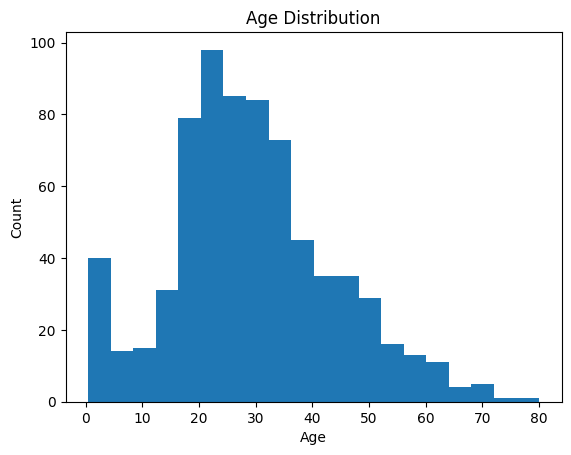

In [12]:
import matplotlib.pyplot as plt

# Age Distribution
plt.figure()
plt.hist(df["Age"].dropna(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

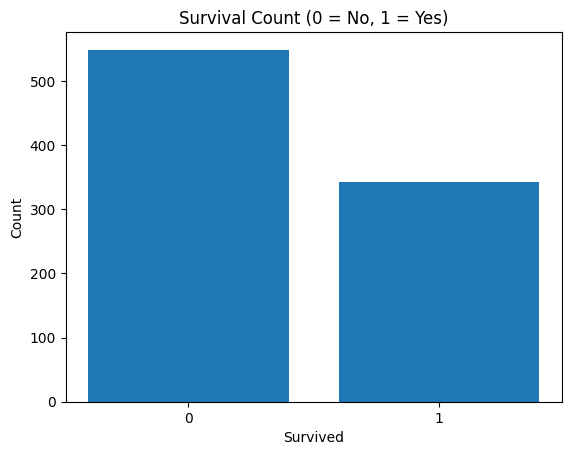

In [13]:
# Survival Count
plt.figure()
counts = df["Survived"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# Preprocessing

In [14]:
# Drop columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [16]:
# Missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
# Encode categorical
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)


In [18]:
print("\nAfter preprocessing:")
print(df.head())


After preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


In [19]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


# Preparing Data

In [23]:
X = df.drop(columns=["Survived"]).astype(float).values
y = df["Survived"].values.reshape(-1, 1)
# Split
np.random.seed(42)
indices = np.random.permutation(len(X))

train_end = int(0.7 * len(X))
val_end = int(0.85 * len(X))

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]


# Feature Scaling

In [24]:
print(df.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [25]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Logistic Regression from scratch

In [26]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000, batch_size=32, l2=0.01):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def initialize(self, n_features):
        self.W = np.zeros((n_features, 1))
        self.b = 0

    def forward(self, X):
        return self.sigmoid(X @ self.W + self.b)

    def compute_loss(self, y, y_hat):
        m = y.shape[0]
        eps = 1e-15
        bce = -(1/m) * np.sum(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        l2_term = (self.l2 / (2*m)) * np.sum(self.W ** 2)
        return bce + l2_term

    def backward(self, X, y, y_hat):
        m = X.shape[0]
        dW = (1/m) * (X.T @ (y_hat - y)) + (self.l2/m) * self.W
        db = (1/m) * np.sum(y_hat - y)
        return dW, db

    def get_batches(self, X, y):
        m = X.shape[0]
        indices = np.random.permutation(m)
        for i in range(0, m, self.batch_size):
            batch_idx = indices[i:i+self.batch_size]
            yield X[batch_idx], y[batch_idx]

    def fit(self, X, y):
        self.initialize(X.shape[1])
        self.losses = []

        for epoch in range(self.epochs):
            for X_batch, y_batch in self.get_batches(X, y):
                y_hat = self.forward(X_batch)
                dW, db = self.backward(X_batch, y_batch, y_hat)
                self.W -= self.lr * dW
                self.b -= self.lr * db

            loss = self.compute_loss(y, self.forward(X))
            self.losses.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward(X)


# Training Model

In [27]:
model = LogisticRegressionScratch()
model.fit(X_train, y_train)

Epoch 0, Loss: 0.6667
Epoch 100, Loss: 0.4321
Epoch 200, Loss: 0.4291
Epoch 300, Loss: 0.4288
Epoch 400, Loss: 0.4288
Epoch 500, Loss: 0.4288
Epoch 600, Loss: 0.4288
Epoch 700, Loss: 0.4288
Epoch 800, Loss: 0.4287
Epoch 900, Loss: 0.4288


# Evaluation

In [28]:
def accuracy(y, y_pred):
    return np.mean(y == y_pred)

def precision(y, y_pred):
    tp = np.sum((y == 1) & (y_pred == 1))
    fp = np.sum((y == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-15)

def recall(y, y_pred):
    tp = np.sum((y == 1) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-15)

def f1(y, y_pred):
    p = precision(y, y_pred)
    r = recall(y, y_pred)
    return 2 * p * r / (p + r + 1e-15)


y_pred = model.predict(X_test)

print("\nFinal Results:")
print("Accuracy:", accuracy(y_test, y_pred))
print("Precision:", precision(y_test, y_pred))
print("Recall:", recall(y_test, y_pred))
print("F1 Score:", f1(y_test, y_pred))


Final Results:
Accuracy: 0.7910447761194029
Precision: 0.68
Recall: 0.7391304347826086
F1 Score: 0.7083333333333328


# Loss curve

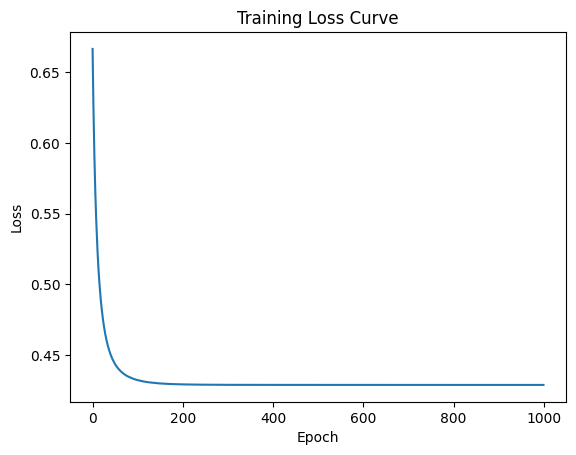

In [29]:
plt.figure()
plt.plot(model.losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ROC Curve + AUC from scratch

AUC : 0.8748764822134387


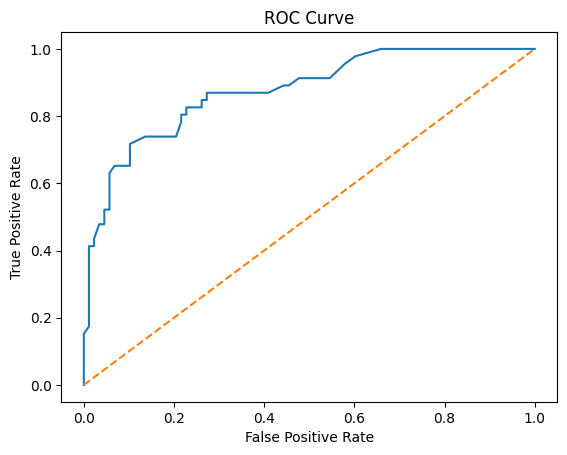

In [32]:
def roc_curve_manual(y_true, probs):
    thresholds = np.linspace(0, 1, 100)
    tprs = []
    fprs = []

    for t in thresholds:
        y_pred = (probs >= t).astype(int)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr = tp / (tp + fn + 1e-15)  # Recall
        fpr = fp / (fp + tn + 1e-15)

        tprs.append(tpr)
        fprs.append(fpr)

    return np.array(fprs), np.array(tprs)


def auc_manual(fprs, tprs):
    # Trapezoidal rule
    sorted_idx = np.argsort(fprs)
    fprs = fprs[sorted_idx]
    tprs = tprs[sorted_idx]
    return np.trapezoid(tprs, fprs)


# Compute ROC
y_probs = model.predict_proba(X_test)
fprs, tprs = roc_curve_manual(y_test, y_probs)
auc_score = auc_manual(fprs, tprs)

print("AUC :", auc_score)


# Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fprs, tprs)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Comparison with sklearn

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train sklearn model
sk_model = LogisticRegression(max_iter=1000)
sk_model.fit(X_train, y_train.ravel())

# Predictions
sk_preds = sk_model.predict(X_test)
sk_probs = sk_model.predict_proba(X_test)[:, 1]

# Metrics
print("\n--- Sklearn Model ---")
print("Accuracy:", accuracy_score(y_test, sk_preds))
print("Precision:", precision_score(y_test, sk_preds))
print("Recall:", recall_score(y_test, sk_preds))
print("F1 Score:", f1_score(y_test, sk_preds))
print("ROC-AUC:", roc_auc_score(y_test, sk_probs))


print("\n--- My Model ---")
print("Accuracy:", accuracy(y_test, y_pred))
print("Precision:", precision(y_test, y_pred))
print("Recall:", recall(y_test, y_pred))
print("F1 Score:", f1(y_test, y_pred))
print("ROC-AUC:", auc_score)


--- Sklearn Model ---
Accuracy: 0.7910447761194029
Precision: 0.68
Recall: 0.7391304347826086
F1 Score: 0.7083333333333334
ROC-AUC: 0.8769762845849802

--- My Model ---
Accuracy: 0.7910447761194029
Precision: 0.68
Recall: 0.7391304347826086
F1 Score: 0.7083333333333328
ROC-AUC: 0.8748764822134387


# Feature Importance

In [34]:
feature_names = df.drop(columns=["Survived"]).columns

weights = model.W.flatten()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": weights
})

importance_df["Abs_Weight"] = np.abs(importance_df["Weight"])
importance_df = importance_df.sort_values(by="Abs_Weight", ascending=False)

print("\nFeature Importance:")
print(importance_df[["Feature", "Weight"]])


Feature Importance:
      Feature    Weight
1         Sex  1.330315
0      Pclass -0.987347
2         Age -0.575547
3       SibSp -0.415568
5        Fare  0.156699
7  Embarked_S -0.141104
4       Parch -0.074659
6  Embarked_Q -0.047510


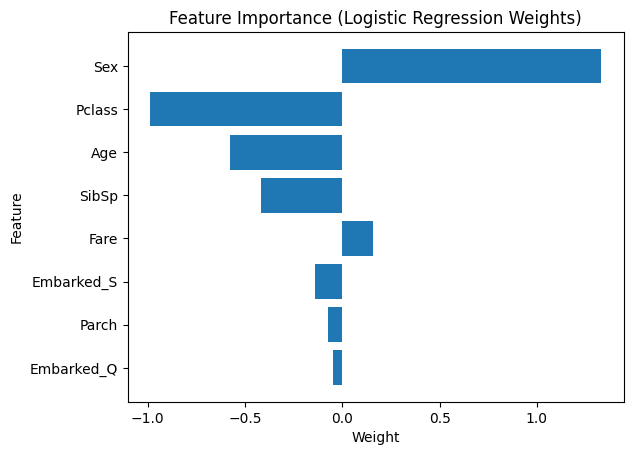

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Weight"])
plt.title("Feature Importance (Logistic Regression Weights)")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()